# 01 - Data Preprocessing

This notebook loads transaction data and creates daily time-series targets:
- `daily_revenue` (sum of Purchase_Amount)
- `daily_orders` (count of transactions)

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'Walmart_customer_purchases.csv'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('Data path:', DATA_PATH)

Data path: c:\Users\RITIK SINHA\Downloads\wakmart-timeseries-forecasting\walmart\data\Walmart_customer_purchases.csv


In [12]:
df = pd.read_csv(DATA_PATH)
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], errors='coerce')
df['Purchase_Amount'] = pd.to_numeric(df['Purchase_Amount'], errors='coerce')

before = len(df)
df = df.dropna(subset=['Purchase_Date', 'Purchase_Amount']).drop_duplicates().copy()
after = len(df)

print(f'Rows before cleaning: {before}')
print(f'Rows after cleaning : {after}')
df.head()

Rows before cleaning: 50000
Rows after cleaning : 50000


,Customer_ID,Age,Gender,City,Category,Product_Name,Purchase_Date,Purchase_Amount,Payment_Method,Discount_Applied,Rating,Repeat_Customer
0,84607c1f-910c-44d5-b89f-e1ee06dd34c0,49,Female,New Cynthia,Electronics,Smartphone,2024-08-30,253.26,Cash on Delivery,No,1,Yes
1,f2a81712-a73e-4424-8b39-4c615a0bd4ea,36,Other,Cruzport,Clothing,T-Shirt,2024-12-21,73.19,Debit Card,Yes,1,No
2,da9be287-8b0e-4688-bccd-1a2cdd7567c6,52,Male,Jeffreytown,Beauty,Perfume,2024-12-26,125.62,Credit Card,Yes,1,No
3,50ec6932-3ac7-492f-9e55-4b148212f302,47,Female,Jenniferburgh,Electronics,Smartwatch,2024-11-04,450.32,Credit Card,No,2,Yes
4,8fdc3098-fc75-4b0f-983c-d8d8168c6362,43,Other,Kingshire,Electronics,Smartphone,2024-10-07,369.28,Credit Card,Yes,2,Yes


In [13]:
daily_revenue = (
    df.groupby(df['Purchase_Date'].dt.date)['Purchase_Amount']
      .sum()
      .rename('daily_revenue')
      .pipe(lambda s: s.set_axis(pd.to_datetime(s.index)))
      .sort_index()
)

daily_orders = (
    df.groupby(df['Purchase_Date'].dt.date)['Customer_ID']
      .count()
      .rename('daily_orders')
      .pipe(lambda s: s.set_axis(pd.to_datetime(s.index)))
      .sort_index()
)

full_idx = pd.date_range(
    start=min(daily_revenue.index.min(), daily_orders.index.min()),
    end=max(daily_revenue.index.max(), daily_orders.index.max()),
    freq='D'
)

daily_revenue = daily_revenue.reindex(full_idx, fill_value=0.0)
daily_orders = daily_orders.reindex(full_idx, fill_value=0.0)

daily_df = pd.concat([daily_revenue, daily_orders], axis=1)
daily_df.index.name = 'date'
daily_df.head()

,daily_revenue,daily_orders
date,,
2024-02-10,31740.30,122
2024-02-11,37996.92,141
2024-02-12,35297.50,139
2024-02-13,40122.00,150
2024-02-14,35806.81,152


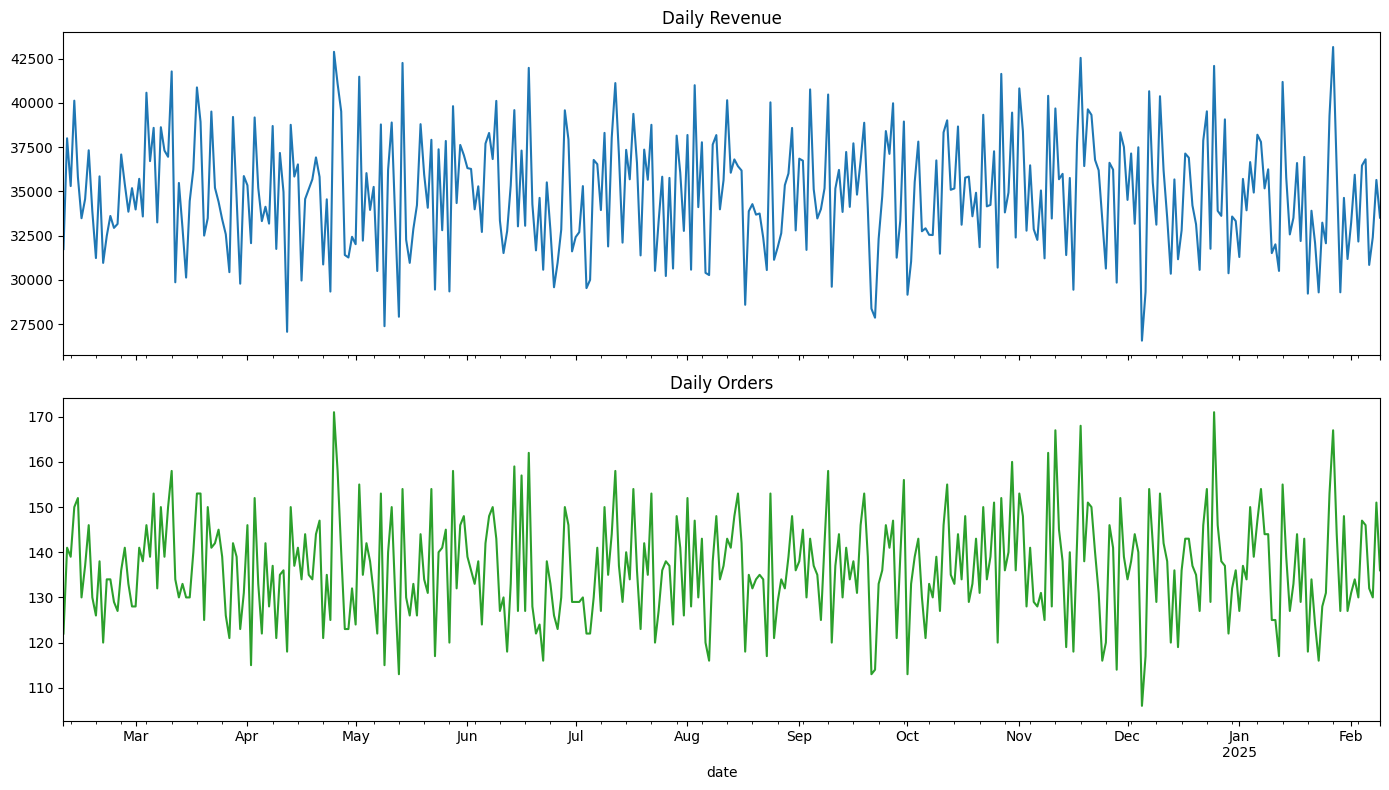

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
daily_df['daily_revenue'].plot(ax=axes[0], color='tab:blue', title='Daily Revenue')
daily_df['daily_orders'].plot(ax=axes[1], color='tab:green', title='Daily Orders')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '01_daily_series.png', dpi=140)
plt.show()

In [ ]:
daily_df.to_csv(ARTIFACTS_DIR / 'daily_series.csv')
print('Saved:', ARTIFACTS_DIR / 'daily_series.csv')

Saved: c:\Users\RITIK SINHA\Downloads\wakmart-timeseries-forecasting\walmart\artifacts\daily_series.csv


: 